# Logistic Regression Project Exercise

**GOAL: Create a Classification Model that can predict whether or not a person has presence of heart disease based on physical features of that person (age,sex, cholesterol, etc...)**

**Complete the TASKs written in bold below.**

## Imports

**TASK: Run the cell below to import the necessary libraries.**

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Data

This database contains 14 physical attributes based on physical testing of a patient. Blood samples are taken and the patient also conducts a brief exercise test. The "goal" field refers to the presence of heart disease in the patient. It is integer (0 for no presence, 1 for presence). In general, to confirm 100% if a patient has heart disease can be quite an invasive process, so if we can create a model that accurately predicts the likelihood of heart disease, we can help avoid expensive and invasive procedures.

Content

Attribute Information:

* age
* sex
* chest pain type (4 values)
* resting blood pressure
* serum cholestoral in mg/dl
* fasting blood sugar > 120 mg/dl
* resting electrocardiographic results (values 0,1,2)
* maximum heart rate achieved
* exercise induced angina
* oldpeak = ST depression induced by exercise relative to rest
* the slope of the peak exercise ST segment
* number of major vessels (0-3) colored by flourosopy
* thal: 3 = normal; 6 = fixed defect; 7 = reversable defect
* target:0 for no presence of heart disease, 1 for presence of heart disease

Original Source: https://archive.ics.uci.edu/ml/datasets/Heart+Disease


**TASK: Run the cell below to read in the data.**

In [2]:
df = pd.read_csv('heart.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [6]:
df['target'].value_counts()  # 0=No Disease, 1=Disease

target
1    165
0    138
Name: count, dtype: int64

# Machine Learning

## Train | Test Split and Scaling

**TASK: Separate the features from the labels into 2 objects, X and y.**

In [9]:
X = df.drop('target', axis=1)
y = df['target']

**TASK: Perform a train test split on the data, with the test size of 10% and a random_state of 101.**

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=101)

**TASK: Create a StandardScaler object and normalize the X train and test set feature data. Make sure you only fit to the training data to avoid data leakage (data knowledge leaking from the test set).**

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_X_train = scaler.fit_transform(X_train)
scaled_X_test = scaler.transform(X_test)

## Logistic Regression Model

**TASK: Create a Logistic Regression model

In [13]:
from sklearn.linear_model import LogisticRegression

In [14]:
log_model = LogisticRegression()

In [15]:
log_model.fit(scaled_X_train,y_train)

LogisticRegression()

### Coeffecients

**TASK: Report back the model's coefficients.**

In [ ]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': log_model.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)

In [17]:
print(coef_df.to_string(index=False))

 Feature  Coefficient
      cp     0.893714
      ca    -0.850807
     sex    -0.734596
    thal    -0.574687
 oldpeak    -0.527225
 thalach     0.433264
   exang    -0.428235
   slope     0.380981
trestbps    -0.262495
    chol    -0.212186
 restecg     0.120366
     age    -0.072445
     fbs     0.045964


## Model Performance Evaluation

**TASK: Let's now evaluate your model on the remaining 10% of the data, the test set.**

**TASK: Create the following evaluations:**
* Confusion Matrix Array
* Confusion Matrix Plot
* Classification Report

In [ ]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from sklearn.metrics import ConfusionMatrixDisplay

In [20]:
y_pred = log_model.predict(scaled_X_test)

In [22]:
accuracy_score(y_test,y_pred)

0.8387096774193549

In [23]:
confusion_matrix(y_test,y_pred)

array([[12,  3],
       [ 2, 14]])

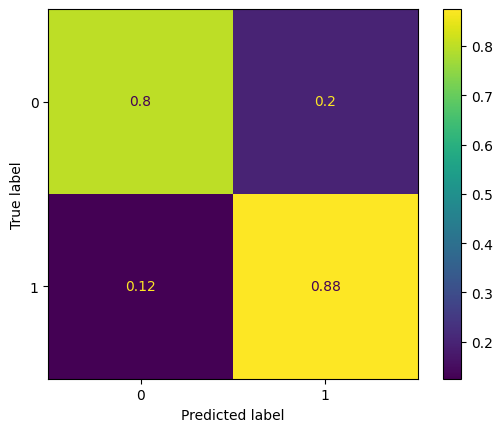

In [24]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    normalize='true'
)

In [25]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.86      0.80      0.83        15
           1       0.82      0.88      0.85        16

    accuracy                           0.84        31
   macro avg       0.84      0.84      0.84        31
weighted avg       0.84      0.84      0.84        31



### Performance Curves

**TASK: Create the ROC Curve.**

c:\Users\win10\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


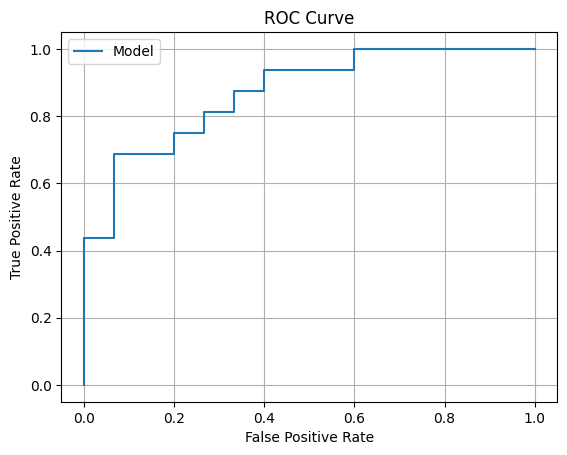

In [26]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = log_model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr, label="Model")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()

plt.show()

In [27]:
fpr, tpr, thresholds

(array([0.        , 0.        , 0.        , 0.06666667, 0.06666667,
        0.2       , 0.2       , 0.26666667, 0.26666667, 0.33333333,
        0.33333333, 0.4       , 0.4       , 0.6       , 0.6       ,
        1.        ]),
 array([0.    , 0.0625, 0.4375, 0.4375, 0.6875, 0.6875, 0.75  , 0.75  ,
        0.8125, 0.8125, 0.875 , 0.875 , 0.9375, 0.9375, 1.    , 1.    ]),
 array([           inf, 6.07217123e-01, 8.71925155e-07, 6.06804464e-07,
        6.20528152e-12, 4.13435878e-12, 1.70501039e-12, 1.51144669e-12,
        2.46464256e-14, 2.10684099e-14, 1.84080856e-14, 2.98985036e-15,
        7.86156241e-16, 2.72429911e-18, 1.63397977e-18, 8.99851478e-27]))

In [28]:
roc_auc_score(y_test, y_prob)

np.float64(0.8708333333333333)

**Final Task: A patient with the following features has come into the medical office:**

    age          48.0
    sex           0.0
    cp            2.0
    trestbps    130.0
    chol        275.0
    fbs           0.0
    restecg       1.0
    thalach     139.0
    exang         0.0
    oldpeak       0.2
    slope         2.0
    ca            0.0
    thal          2.0

**TASK: What does your model predict for this patient? Do they have heart disease? How "sure" is your model of this prediction?**

*For convience, we created an array of the features for the patient above*

In [ ]:
patient = np.array([[48.0, 0.0, 2.0, 130.0, 275.0, 0.0,
                     1.0, 139.0, 0.0, 0.2, 2.0, 0.0, 2.0]])

patient_scaled = scaler.transform(patient)

prediction  = log_model.predict(patient_scaled)
probability = log_model.predict_proba(patient_scaled)

print("PATIENT PREDICTION RESULTS")
print("=" * 50)
print(f"Predicted Class : {prediction[0]}  ({'Heart Disease PRESENT' if prediction[0]==1 else 'Heart Disease ABSENT'})")
print()
print(f"P(No Disease)   : {probability[0][0]:.1%}")
print(f"P(Disease)      : {probability[0][1]:.1%}")
print()
confidence = max(probability[0])
level = 'HIGH' if confidence > 0.80 else 'MODERATE' if confidence > 0.60 else 'LOW'
print(f"Model Confidence: {level} ({confidence:.1%})")
print()

#female patient, no chest pain due to exercise, very low ST depression which is a heart stress indicator, no major vessels blocked.


PATIENT PREDICTION RESULTS
Predicted Class : 1  (Heart Disease PRESENT)

P(No Disease)   : 2.0%
P(Disease)      : 98.0%

Model Confidence: HIGH (98.0%)

Clinical context:
48-year-old female, non-anginal chest pain, no exertional angina,
low ST depression (oldpeak=0.2) — generally lower-risk profile.


c:\Users\win10\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
